# Exercícios de Regressão Logística e Classificação Binária

#Exercício 1:

A Regressão Logística funciona em duas etapas:


## 1. Parte Linear

Primeiro, o modelo calcula:

$$
z = w_1 x_1 + w_2 x_2 + b
$$

onde:

- $x_1$ e $x_2$ são as entradas (features)  
- $w_1$ e $w_2$ são os pesos  
- $b$ é o bias (ajuste)



## 2. Função Sigmoide

Depois, aplica a função sigmoide:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Isso transforma o valor em uma **probabilidade entre 0 e 1**.


## Tarefa 1

Suponha que o modelo aprendeu:

- $w_1 = 2.0$  
- $w_2 = -1.0$  
- $b = 0.5$

E temos um ponto:

- $x_1 = 1.2$  
- $x_2 = -0.3$


### a) Calcule o valor de $z$

$$
z = w_1 x_1 + w_2 x_2 + b
$$


### b) Calcule a probabilidade

$$
\hat{y} = \frac{1}{1 + e^{-z}}
$$


### c) Classificação final

- Se $\hat{y} > 0.5$ → Classe 1  
- Caso contrário → Classe 0  



## Tarefa 2

Responda com suas próprias palavras:

1. O que representam $w_1$ e $w_2$?  
2. Qual o papel do $b$?  
3. Por que usamos a função sigmoide?

Dica:

- $w$ → importância de cada variável  
- $b$ → ajuste da linha  
- Sigmoide → transforma em probabilidade
---

# Resolução:
1.a)
Valor de z: $w1*x1 + w2*x2 + b$

$z = (2 * 1.2) + ((-1.0) * (-0.3)) + 0.5 = 3.2$

A conta foi feita substituindo os valores dados de w1, x1, w2, x2 e b na fórmula dada

1.b e c) Valor da probabilidade: $$
\hat{y} = \frac{1}{1 + e^{-z}}
$$

$$
\hat{y} = \frac{1}{1 + e^{-3.2}} = 0.9608
$$

O valor da probablidade é dado pela formula: $$
\hat{y} = \frac{1}{1 + e^{-z}}
$$

Ao substituir z pelo valor encontrado na questão 1 obtivemos o valor de 0.9608 o que indica que a probabilidade está "pendendo" para a classe 1 (probabilidade > 0.5)

2.1) w1 significa o peso de treinamento da variavel x1, basicamente é a influência da variável 1 (entrada 1) na decisão do modelo, quanto maior o w1 maior a influência de x1 no resultado final, já o w2 é a mesma coisa mas está relacionado com a variavel x2

2.2) b significa bias (vies), se w1x1 e w2x2 resultarem em 0 o modelo linear não iria ser zerado e sim ter o valor do vies. Ele serve para ajustar a predição independentemente dos valores de entrada

2.3) Transforma qualquer valor real em um número entre 0 e 1 (faz a função probabilidade resultar entre 0 e 1). Se for > 0.5 é da classe 1 e se for < 0.5 não é da classe 1 e sim da classe 0

---


  

# Exercício 2:

Neste exercício, você vai criar um código semelhante ao exemplo visto em aula para treinar um modelo de **Regressão Logística**.


# Tarefa

Implemente um classificador binário seguindo os seguintes dados:

Crie duas classes:

- Classe 0: centrada em (-2, -2)  
- Classe 1: centrada em (2, 2)  

Use distribuição normal para gerar os pontos.

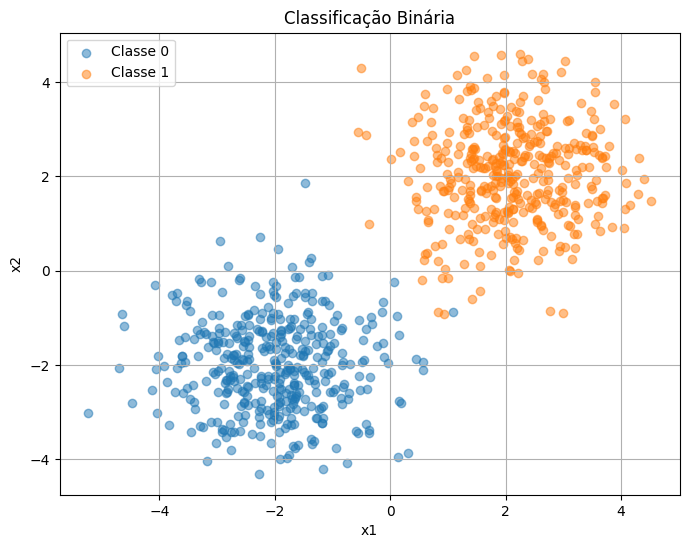

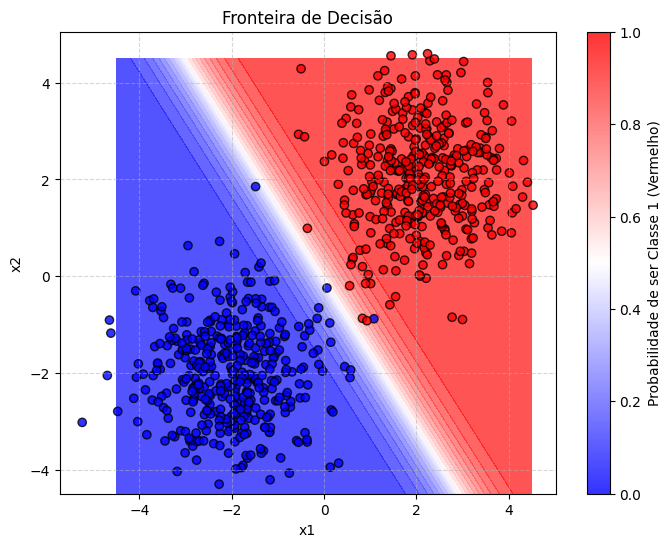

[1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1.
 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.
 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0.
 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 1.
 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 0.
 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0.
 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1.
 0. 1. 1. 0. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0.
 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

np.random.seed(42)

N = 400

# Classe 0
x0 = np.random.randn(N, 2) + np.array([-2, -2]) # esse '+ np.array([-2, -2]) faz ser centrado em -2, -2
y0 = np.zeros(N) # aqui é zeros (para y0)

# Classe 1
# centrada em 2 e 2
x1 = np.random.randn(N, 2) + np.array([2, 2])
y1 = np.ones(N) # aqui é ones (para y1)

# Juntar dados
X = np.vstack([x0, x1]) # v de vertical, empilha verticalmente x0 e x1 (une eles)
Y = np.hstack([y0, y1]) # h de horizontal, empilha horizontalmente y0 e y1 (une eles)

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split( # X_train e Y_train: Treina o modelo com 70% dos dados
    X, Y, test_size=0.3, random_state=42 # X_test e y_test: Testa o desempenho do modelo com 30% dos dados
) # random_state definido garante reprodutibilidade (obter resultados iguais)

# Treinar modelo
model = LogisticRegression() # instância do modelo de regressão linear
model.fit(X_train, y_train) # treina o modelo usando os dados de treino

# Predição
y_pred = model.predict(X_test) # faz previsões sobre a classe dos dados no conjunto de teste (X_test), o resultado y_pred contém 0s ou 1s dependendo da classe prevista (classe 0 ou classe 1)

# Plot dos dados
plt.figure(figsize=(8,6))

plt.scatter(x0[:,0], x0[:,1], alpha=0.5, label="Classe 0")
plt.scatter(x1[:,0], x1[:,1], alpha=0.5, label="Classe 1")

plt.title("Classificação Binária")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Fronteira de decisão
xx, yy = np.meshgrid(np.linspace(-4.5, 4.5, 200), #cria uma grade de pontos entre -4.5 e 4.5
                     np.linspace(-4.5, 4.5, 200)) # pega dois arrays e transforma em uma matriz

grid = np.c_[xx.ravel(), yy.ravel()] # transforma as matrizes xx e yy em vetores, np.c empilha horizontalmente
probs = model.predict_proba(grid)[:, 1].reshape(xx.shape) # faz com que o modelo preveja a probabilidade de cada ponto na grde de pertencer a uma classe ou outra

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, probs, levels=20, alpha=0.7, cmap="bwr") #cores

plt.scatter(X[:,0], X[:,1], c=Y, edgecolor="k", cmap="bwr", alpha=0.8) #cores

plt.title("Fronteira de Decisão")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="Probabilidade de ser Classe 1 (Vermelho)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
print(y_pred)

## Desafio:

Simule um dataset de saúde, onde a probabilidade de risco é dada por uma função logística.

Probabilidade:

$$ p = \frac{1}{1 + e^{-(0.03 \cdot P + 0.02 \cdot C - 10)}} $$

Tarefas
* Simular 700 pacientes.
* Calcular $p$ usando a fórmula acima.
* Gerar a classe $y$.
* Treinar regressão logística.

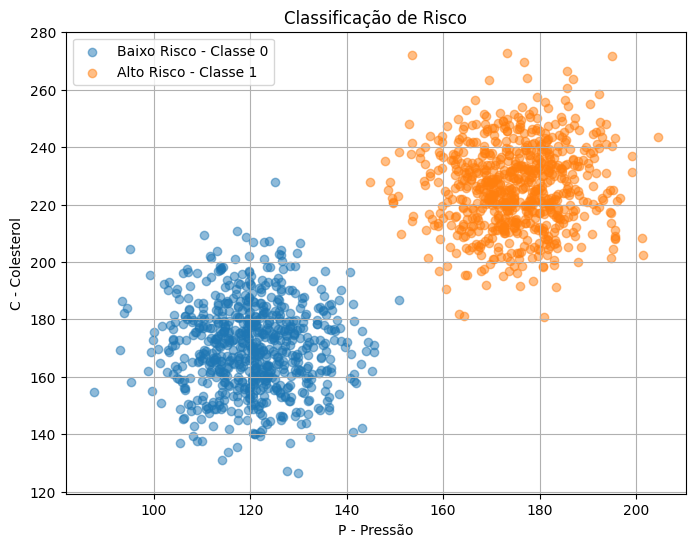

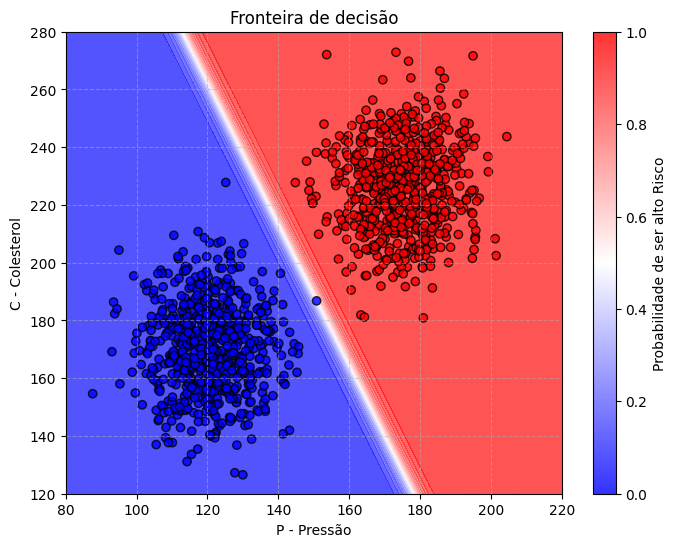

[0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 1. 0. 1. 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1.
 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 0.
 1. 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1.
 1. 1. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0.
 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1.
 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1.
 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1.
 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 1. 1. 1. 0. 1.
 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1.
 0. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

np.random.seed(42) # reproduzivel (mesmos resultados aleatorios em todas as execuções)

N = 350 # 2 * N = 700 pacientes , N é o número de pacientes gerado em cada classe

# Classe 0 baixo risco
# centrada em P = 120 e C = 170
x0 = np.random.randn(N, 2) * np.array([10, 15]) + np.array([120, 170])
y0 = np.zeros(N)

# Classe 1 alto risco
# centrada em P = 175 e C = 225
x1 = np.random.randn(N, 2) * np.array([10, 15]) + np.array([175, 225])
y1 = np.ones(N)

# Juntar dados
X = np.vstack([x0, x1])
Y = np.hstack([y0, y1])

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

# Treinar modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Predição
y_pred = model.predict(X_test)

# Plot dos dados
plt.figure(figsize=(8, 6))

plt.scatter(x0[:, 0], x0[:, 1], alpha=0.5, label="Baixo Risco - Classe 0")
plt.scatter(x1[:, 0], x1[:, 1], alpha=0.5, label="Alto Risco - Classe 1")

plt.title("Classificação de Risco")
plt.xlabel("P - Pressão")
plt.ylabel("C - Colesterol")
plt.legend()
plt.grid(True)
plt.show()

# Fronteira de decisão
xx, yy = np.meshgrid(
    np.linspace(80, 220, 200),
    np.linspace(120, 280, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, probs, levels=20, alpha=0.7, cmap="bwr")

plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolor="k", cmap="bwr", alpha=0.8)

plt.title("Fronteira de decisão")
plt.xlabel("P - Pressão")
plt.ylabel("C - Colesterol")
plt.colorbar(label="Probabilidade de ser alto Risco")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print(y_pred)